In [3]:
from lsst.rsp import get_tap_service, retrieve_query
from lsst.utils.plotting import set_rubin_plotstyle, stars_cmap, get_multiband_plot_colors 
from statsmodels.distributions.empirical_distribution import ECDF
import matplotlib.pyplot as plt
import numpy as np
from lsst.daf.butler import Butler

colors = get_multiband_plot_colors()
bands = colors.keys()

In [5]:
instrument = 'LSSTComCam'
collections = ['skymaps',
               'LSSTComCam/DP1',
               'LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260' ]
skymap = 'lsst_cells_v1'
butler = Butler("/repo/dp1",
                instrument=instrument, 
                collections=collections, 
                skymap=skymap)
registry = butler.registry
skymap = butler.get('skyMap', skymap=skymap)

In [6]:
table = butler.get('visit_detector_table')

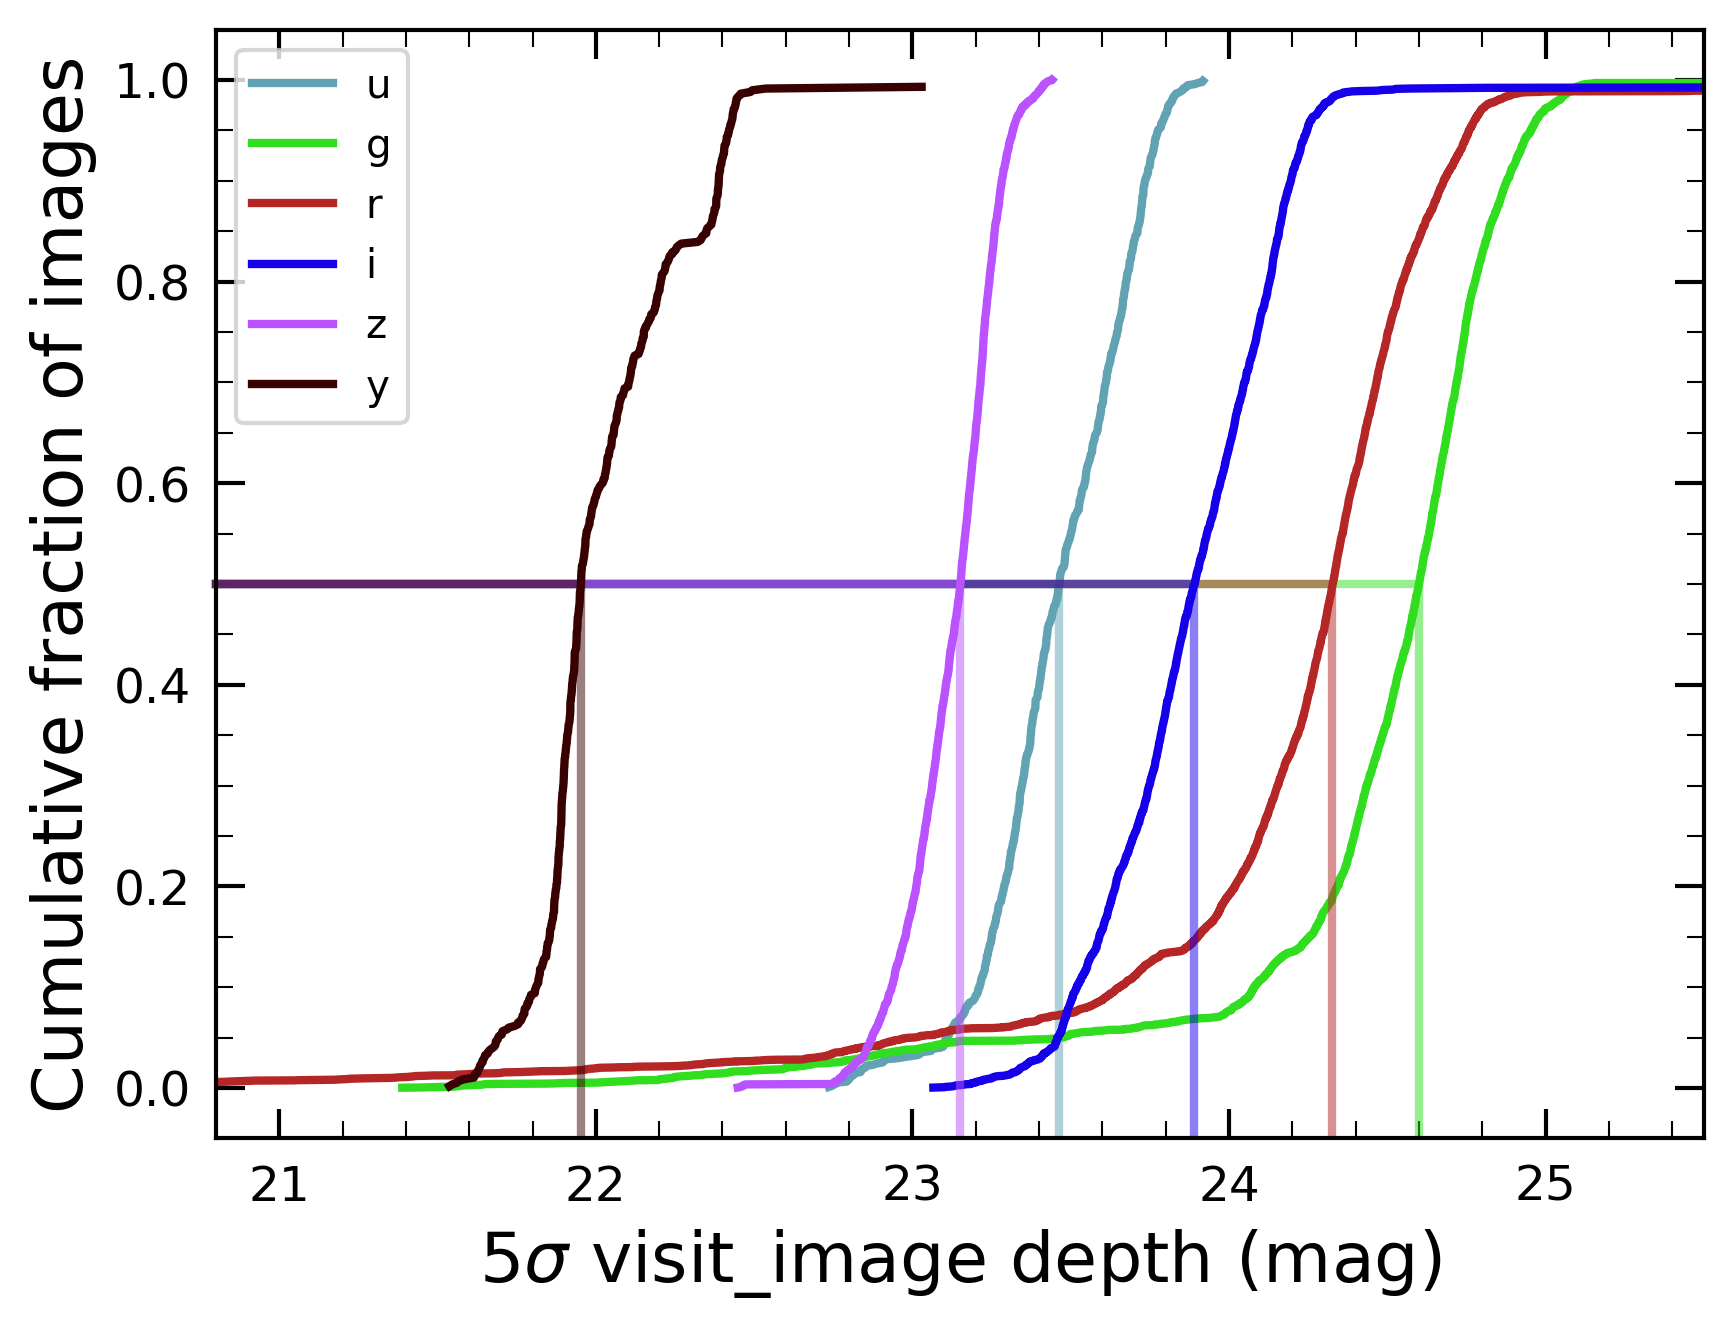

In [23]:
set_rubin_plotstyle()
colors = get_multiband_plot_colors()
bands = colors.keys()

for band in bands:
    data = table['magLim'][table['band']==band]
    ecdf = ECDF(data)
    plt.plot(ecdf.x, ecdf.y,
             linestyle='-', label=band, color=colors[band])
    plt.plot([20.8, np.nanmedian(data), np.nanmedian(data)],[0.5,0.5,-0.045],
             color=colors[band], alpha=0.5, clip_on=False)

plt.xlim(20.8, 25.5)
plt.ylim(-0.05, 1.05)
plt.legend()
plt.xlabel(r'$5\sigma$ visit_image depth (mag)')
plt.ylabel('Cumulative fraction of images')

plt.savefig(
   "../dp1_visit_image_depth_cum_hist.pdf", 
   bbox_inches="tight",  # Trim whitespace around the figure
   transparent=True,     # Transparent background
   format="pdf",         # Explicit format specification
)

plt.show()